In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Step 2 - Load the strategy data

In [2]:
spy = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/spy.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')   # change if needed
spy.columns = spy.columns.str.strip()

spy = pd.DataFrame({'Adj_Close': spy['Close']})

spy.sort_index(inplace=True)
spy.head()

,Adj_Close
Date,
1993-01-29,43.9375
1993-02-01,44.2500
1993-02-02,44.3438
1993-02-03,44.8125
1993-02-04,45.0000


Step 3 - Rebuild the strategy columns if needed

In [3]:
short_window = 50
long_window = 200
transaction_cost = 0.001

spy["simple_return"] = spy["Adj_Close"].pct_change()
spy["ma_short"] = spy["Adj_Close"].rolling(short_window).mean()
spy["ma_long"] = spy["Adj_Close"].rolling(long_window).mean()
spy["signal_raw"] = (spy["ma_short"] > spy["ma_long"]).astype(int)
spy["signal"] = spy["signal_raw"].shift(1)
spy["trade"] = spy["signal"].diff().abs().fillna(0)
spy["strategy_return_net"] = spy["signal"] * spy["simple_return"] - spy["trade"] * transaction_cost
spy["equity_net"] = (1 + spy["strategy_return_net"]).cumprod()
spy["equity_bh"] = (1 + spy["simple_return"]).cumprod()

spy = spy.dropna(subset=["simple_return", "strategy_return_net"])

Step 4 - Plot the daily return series

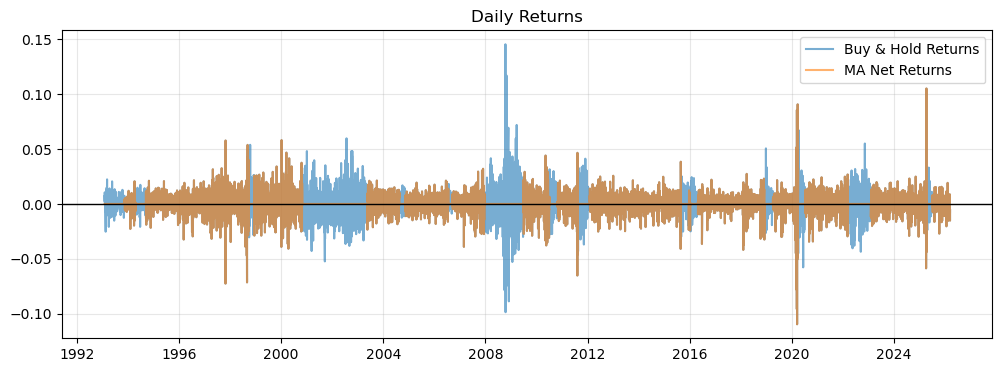

In [4]:
plt.figure(figsize=(12,4))
plt.plot(spy.index, spy["simple_return"], label="Buy & Hold Returns", alpha=0.6)
plt.plot(spy.index, spy["strategy_return_net"], label="MA Net Returns", alpha=0.6)
plt.axhline(0, color="black", linewidth=1)
plt.title("Daily Returns")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- The strategy returns are smoother than the buy and hold method, not a huge difference - key significant ones are the crashes.
- No long flat periods, other than during the early 2000s and 2008s
- Yes, there are huge spikes in both directions - especially during stressful periods in the market plus other moments showing weaknesses.  

Step 5 - Build rolling volatility

Now calculating how volatility changes through time

In [5]:
window = 30

spy["roll_vol_bh"] = spy["simple_return"].rolling(window).std() * np.sqrt(252)
spy["roll_vol_net"] = spy["strategy_return_net"].rolling(window).std() * np.sqrt(252)

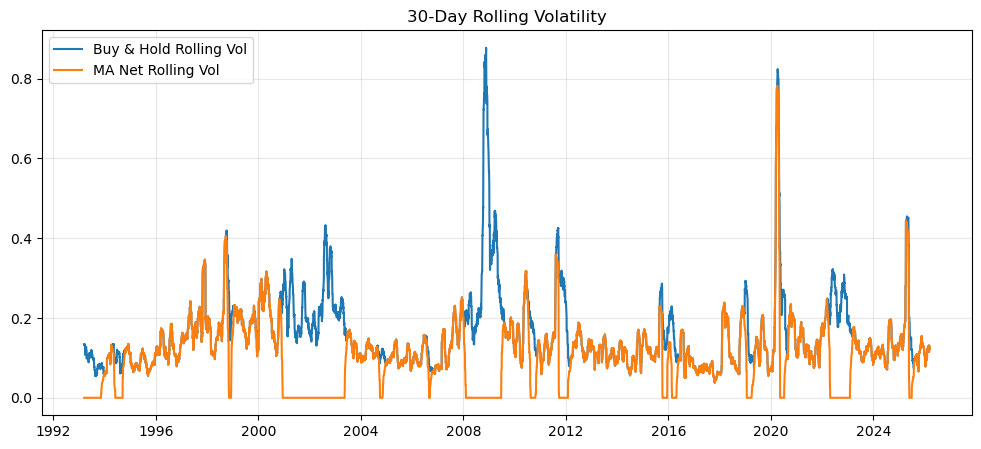

In [6]:
plt.figure(figsize=(12,5))
plt.plot(spy.index, spy["roll_vol_bh"], label="Buy & Hold Rolling Vol")
plt.plot(spy.index, spy["roll_vol_net"], label="MA Net Rolling Vol")
plt.title("30-Day Rolling Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- Volatility does not rise during ALL stressful market periods, prior the covid crash it does NOT rise during crashes. Howeverm during covid we see a huge spike and during oil price spikes
- Clear to see strategy reduces volatility
- Fairly stable, has some erratic moments - however can see some stability

Step 6 - Build rolling sharpe

Helps to see if performance is consistent or only appears in certain windows

In [7]:
def rolling_sharpe(returns, window=30):
    mean = returns.rolling(window).mean()
    std = returns.rolling(window).std()
    return (mean / std) * np.sqrt(252)

spy["roll_sharpe_bh"] = rolling_sharpe(spy["simple_return"], window)
spy["roll_sharpe_net"] = rolling_sharpe(spy["strategy_return_net"], window)

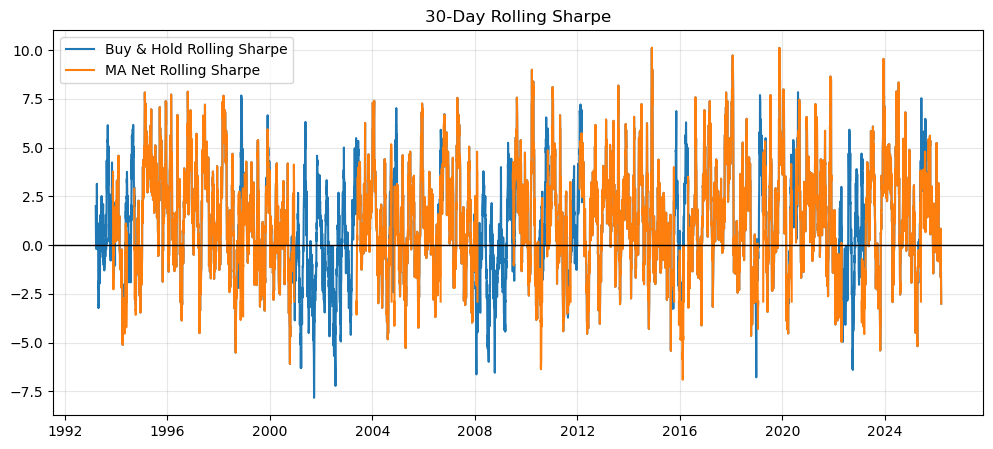

In [8]:
plt.figure(figsize=(12,5))
plt.plot(spy.index, spy["roll_sharpe_bh"], label="Buy & Hold Rolling Sharpe")
plt.plot(spy.index, spy["roll_sharpe_net"], label="MA Net Rolling Sharpe")
plt.axhline(0, color="black", linewidth=1)
plt.title("30-Day Rolling Sharpe")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- Unstable - as it varies from positive and negative, clear unstability
- No clear advantage in certain periods
- Performance does not disappear quickly - however it is balanced with the equal positive and negative sharpe value which will counteract each other

Step 7 - Plotting rolling drawdown

Drawdown tells us how painful the path is - not just the final result

In [10]:
dd_bh = spy["equity_bh"] / spy["equity_bh"].cummax() - 1
dd_net = spy["equity_net"] / spy["equity_net"].cummax() - 1

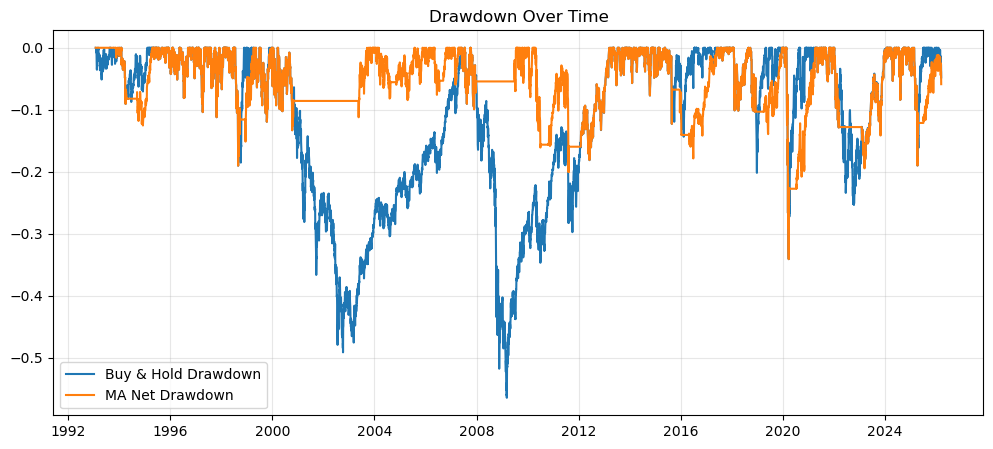

In [11]:
plt.figure(figsize=(12,5))
plt.plot(spy.index, dd_bh, label="Buy & Hold Drawdown")
plt.plot(spy.index, dd_net, label="MA Net Drawdown")
plt.title("Drawdown Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- Clear to see ' Buy and Hold' method suffers a deeper losses than MA strategy
- 8/10 times stratefy recovers faster than the buy and hold - showing a strength in the strat
- Short & shallow for most of the times however the strategy does go through moments of long and painful times

## Rolling behaviour notes
Is the strategy stable over time?
- No, clear to instability in different metrics

Does performance appear in clusters?
- Performance does appear in clusters - clearly noticeable in the return plots
  
Are there long periods where it stops working?
- Yes, during the crashes we see the strat stops working - however the pro of this is Buy and Hold goes through a huge drawdown, which we avoid
  
Does rolling volatility help explain the equity curve?
- Yes, can compare bewteen the two strategies better this way
- 
Does rolling Sharpe confirm or weaken your confidence?
- Rolling sharpe weakens my confidence in this strategy, showing the instability of its returns

In [12]:
rolling_summary = pd.DataFrame({
    "Buy & Hold": [
        spy["roll_vol_bh"].mean(),
        spy["roll_sharpe_bh"].mean(),
        dd_bh.min()
    ],
    "MA Net": [
        spy["roll_vol_net"].mean(),
        spy["roll_sharpe_net"].mean(),
        dd_net.min()
    ]
}, index=["Avg Rolling Vol", "Avg Rolling Sharpe", "Max Drawdown"])

rolling_summary.round(4)

,Buy & Hold,MA Net
Avg Rolling Vol,0.1606,0.1056
Avg Rolling Sharpe,1.2194,1.3138
Max Drawdown,-0.5647,-0.3410
